# PyTorch XLM-RoBERTa base

I will fine-tune `FacebookAI/xlm-roberta-base` with its matching tokenizer for three-way natural-language inference.

Reusable loading, splitting, batching, training, and evaluation code lives in `scripts/watson_model_helpers.py`.

The premise-grouped split evaluates generalization to unseen premises.

## Venv and requirements

Different Python versions were used during development depending on hardware and software constraints. Please see the repository’s [setup documentation](../README.md#setup) for details.

## Model and tokenizer choice

- starting from general pretrained [XLM-RoBERTa base checkpoint](https://huggingface.co/FacebookAI/xlm-roberta-base)
- newly initialized three-label classification head. 
- The tokenizer receives premise first, hypothesis second, with dynamic batch padding and configurable truncation.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "scripts" / "watson_dataset_config.py").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Open this notebook from inside the project repository")
if str(PROJECT_ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "scripts"))

from watson_dataset_helpers import load_datasets
from watson_model_helpers import (
    split_training_data,
    load_model_and_tokenizer,
    tokenize_data,
    make_loaders,
    fine_tune,
    check_bf16_support
)

## Bring in the data

In [2]:
datasets = load_datasets()

training_data = datasets["train"].copy()
test_data = datasets["test"].copy()

Kaggle files already present; using: (project_root)/data/raw


## Training-data preparation and validation split

### Goals in Preparing Training/Validation split:
- No exact premise appears in both training and validation. All rows sharing a premise stay together.
- Have roughly the same label proportions in validation and the training side as a whole.

Note: Proportions are approximate because premise groups stay intact.

In [3]:
training, validation = split_training_data(training_data)

## Data Cleaning

Prior exploration in `01_dataset_exploration.ipynb` found

- no missing values
- no duplicate premise–hypothesis pairs

No further text cleaning is planned; the original premise and hypothesis text will be kept.

## Bring in Pre-Trained Model

### XLM-Roberta Base
- XLM-Roberta Base is chosen as the pre-trained model.
- XLM-Roberta seems like a natural first check.
- Base model chosen to baseline performance using, and acknowledging, local HW constraints
- Other models may be used in the future, either in this notebook or separate notebooks

In [4]:
# Run before model initialization and loader creation for each fresh experiment.
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)  # Seeds CPU and accelerator RNGs, including MPS.
# A fixed seed does not guarantee fully deterministic MPS execution.


In [5]:
model, tokenizer = load_model_and_tokenizer("FacebookAI/xlm-roberta-base")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Tokenization

In [6]:
training_encodings = tokenize_data(training, tokenizer)
validation_encodings = tokenize_data(validation, tokenizer)

## Batching, Padding, Training Settings

In [7]:
batch_size = 32

In [8]:
# learning_rate = 2e-5
# learning_rate = 1e-5
#learning_rate = 1.5e-5
#learning_rate = 5e-6
#learning_rate = 2.5e-6
learning_rate = 7.5e-6 
# learning_rate = 6.25e-6
# learning_rate = 6.875e-6

In [9]:
epochs = 20

In [10]:
# weight_decay = 0.05  # AdamW default: 0.01.
weight_decay = 0.01  # AdamW default: 0.01.

In [11]:
use_bf16 = False  # Training precision.
validation_use_bf16 = False  # Independent validation precision; True enables BF16.

In [12]:
# Each training call creates a unique run folder here; best.pt persists on disk.
checkpoint_dir = PROJECT_ROOT / "data" / "checkpoints" / "xlm-roberta-base"

In [13]:
early_stopping_patience = 2  # Consecutive non-improving epochs; None disables stopping.

In [14]:
min_delta = 0.0  # Minimum loss decrease that resets patience.

In [15]:
# The best weights are restored automatically; checkpoints are not resumable runs.

training_loader, validation_loader = make_loaders(
    training_encodings, validation_encodings, tokenizer, batch_size
)

### GPU memory investigation

Apple MPS out-of-memory issues were encountered during development. Please visit [MPS memory investigation](../docs/investigations/mps-memory.md) for the issues encountered and their resolutions. Please also visit [runtime performance documentation](../docs/runtimes/README.md) for performance findings from the MPS memory investigation.

## Fine-tuning

In [16]:
if use_bf16 or validation_use_bf16:
    check_bf16_support()

training_result = fine_tune(
    model, training_loader, validation_loader, learning_rate, epochs,
    use_bf16=use_bf16, validation_use_bf16=validation_use_bf16,
    checkpoint_dir=checkpoint_dir, weight_decay=weight_decay,
    early_stopping_patience=early_stopping_patience, min_delta=min_delta,
)

2026-09-28 16:11:16 | Training on mps, 303 batches/epoch, 20 epochs, learning rate 7.5e-06, weight decay 0.01, training precision FP32; validation precision FP32
Best checkpoint: /Users/KurtMeehanPro/Documents/code/git/adventure-of-the-lying-detective/data/checkpoints/xlm-roberta-base/run-20260928-161116-xymxfz_l/best.pt
Early stopping: patience=2, min_delta=0.0
2026-09-28 16:11:16 | Processing batch 0/303
2026-09-28 16:12:25 | Epoch 1/20: training loss = 1.1045, validation loss = 1.0987, validation accuracy = 34.46%
Saved best checkpoint: epoch 1, validation loss=1.0987
2026-09-28 16:12:25 | Processing batch 0/303
2026-09-28 16:13:32 | Epoch 2/20: training loss = 1.0767, validation loss = 0.9582, validation accuracy = 54.82%
Saved best checkpoint: epoch 2, validation loss=0.9582
2026-09-28 16:13:33 | Processing batch 0/303
2026-09-28 16:14:40 | Epoch 3/20: training loss = 0.8755, validation loss = 0.7566, validation accuracy = 68.34%
Saved best checkpoint: epoch 3, validation loss=0.7

## Evaluation

### Validation confusion matrix

All languages are pooled. Rows are true classes and columns are predicted classes; each row is normalized to 1.

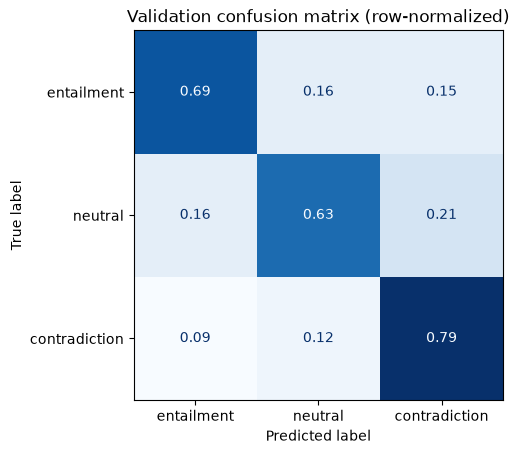

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

label_names = ["entailment", "neutral", "contradiction"]
true_labels = []
predicted_labels = []
class_probabilities = []
device = next(model.parameters()).device

model.eval()
with torch.no_grad():
    for batch in validation_loader:
        batch = {key: value.to(device) for key, value in batch.items()}
        with torch.autocast(
            device_type=device.type, dtype=torch.bfloat16, enabled=validation_use_bf16
        ):
            logits = model(**batch).logits
        probabilities = logits.softmax(dim=-1)
        true_labels.extend(batch["labels"].cpu().tolist())
        predicted_labels.extend(probabilities.argmax(dim=-1).cpu().tolist())
        class_probabilities.extend(probabilities.float().cpu().tolist())

ConfusionMatrixDisplay.from_predictions(
    true_labels, predicted_labels, labels=range(3), display_labels=label_names,
    normalize="true", values_format=".2f", cmap="Blues", colorbar=False,
)
plt.title("Validation confusion matrix (row-normalized)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

### Validation classification metrics

Precision, recall, and F1 are reported for each class. Macro F1 gives every class equal weight.

In [21]:
import pandas as pd
from sklearn.metrics import f1_score, precision_recall_fscore_support

precision, recall, per_class_f1, support = precision_recall_fscore_support(
    true_labels, predicted_labels, labels=range(len(label_names)), zero_division=0
)
per_class_metrics = pd.DataFrame(
    {
        "precision": precision,
        "recall": recall,
        "f1": per_class_f1,
        "support": support,
    },
    index=pd.Index(label_names, name="class"),
)
macro_f1 = f1_score(
    true_labels, predicted_labels, labels=range(len(label_names)),
    average="macro", zero_division=0,
)

display(per_class_metrics.style.format({
    "precision": "{:.4f}", "recall": "{:.4f}", "f1": "{:.4f}"
}))
print(f"Macro F1: {macro_f1:.4f}")

,precision,recall,f1,support
class,,,,
entailment,0.7484,0.6902,0.7181,836
neutral,0.6801,0.6293,0.6537,777
contradiction,0.6859,0.7897,0.7341,813


Macro F1: 0.7020


### Per-class precision–recall curves

Each class is evaluated one-vs-rest using its predicted probability. The dashed line shows that class's prevalence in validation, and AP is average precision.

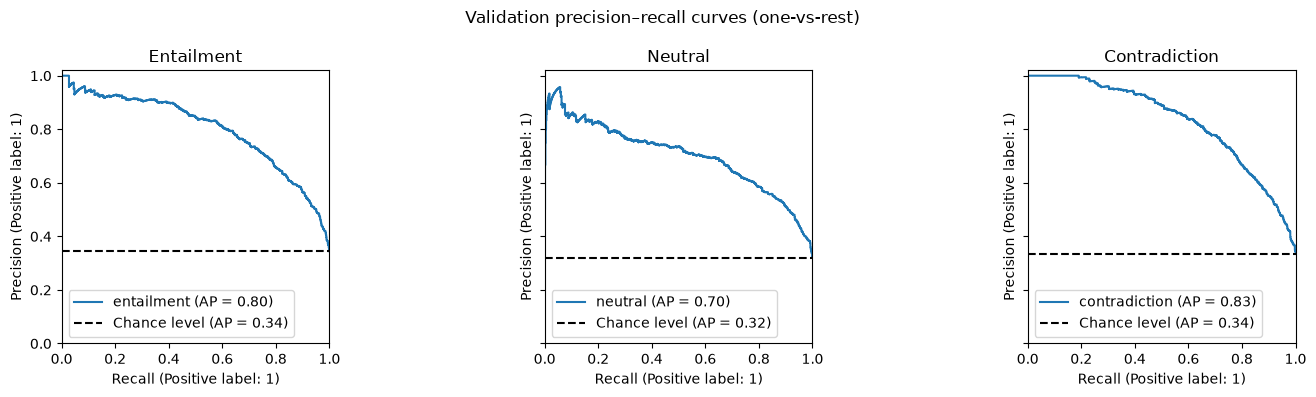

In [22]:
import numpy as np
from sklearn.metrics import PrecisionRecallDisplay

true_label_array = np.asarray(true_labels)
class_probability_array = np.asarray(class_probabilities)
if class_probability_array.shape != (len(true_label_array), len(label_names)):
    raise ValueError("Validation labels and class probabilities are not aligned.")

figure, axes = plt.subplots(1, len(label_names), figsize=(15, 4), sharex=True, sharey=True)
for label_id, (label_name, axis) in enumerate(zip(label_names, axes)):
    binary_true = (true_label_array == label_id).astype(int)
    PrecisionRecallDisplay.from_predictions(
        binary_true, class_probability_array[:, label_id],
        name=label_name, plot_chance_level=True, ax=axis,
    )
    axis.set_title(label_name.capitalize())
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1.02)

figure.suptitle("Validation precision–recall curves (one-vs-rest)")
figure.tight_layout()
plt.show()

### English and Spanish confusion matrices

These use the predictions above, separated by language.

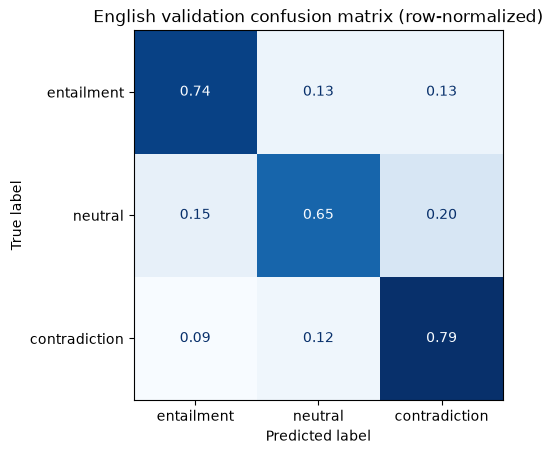

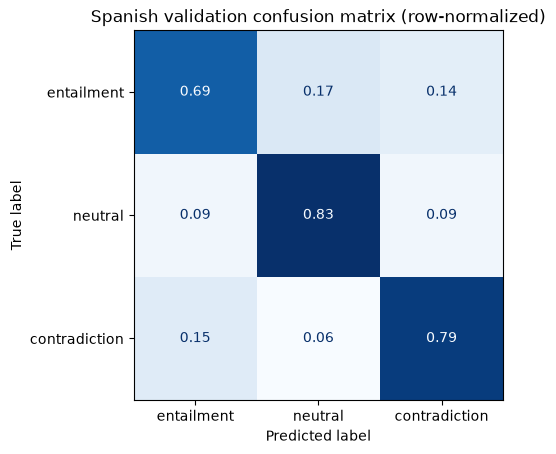

In [23]:
validation_languages = validation["language"].tolist()
if len(validation_languages) != len(true_labels):
    raise ValueError("Validation languages and predictions are not aligned.")

for language in ["English", "Spanish"]:
    indices = [
        index for index, value in enumerate(validation_languages) if value == language
    ]
    language_true = [true_labels[index] for index in indices]
    language_predicted = [predicted_labels[index] for index in indices]

    ConfusionMatrixDisplay.from_predictions(
        language_true, language_predicted, labels=range(3),
        display_labels=label_names, normalize="true", values_format=".2f",
        cmap="Blues", colorbar=False,
    )
    plt.title(f"{language} validation confusion matrix (row-normalized)")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.show()